In [1]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/inventory-optimization-ml-or

!git config --global user.email "smrititubid@gmail.com"
!git config --global user.name "smrititubid-afk"

Mounted at /content/drive
/content/drive/MyDrive/inventory-optimization-ml-or


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("data/processed/features_phase2.csv")

print(df.shape)
df.head()

(197925, 31)


,id,item_id,dept_id,cat_id,store_id,state_id,avg_demand,std_demand,cv,zero_demand_ratio,...,month_num,quarter,year_num,lag_1,lag_7,lag_28,rolling_mean_7,rolling_mean_28,rolling_std_7,rolling_std_28
0,FOODS_1_022_CA_4_validation,FOODS_1_022,FOODS_1,FOODS,CA_4,CA,0.095661,0.398411,4.164373,0.928385,...,2,1,2011,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,FOODS_1_022_CA_4_validation,FOODS_1_022,FOODS_1,FOODS,CA_4,CA,0.095661,0.398411,4.164373,0.928385,...,2,1,2011,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,FOODS_1_022_CA_4_validation,FOODS_1_022,FOODS_1,FOODS,CA_4,CA,0.095661,0.398411,4.164373,0.928385,...,2,1,2011,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,FOODS_1_022_CA_4_validation,FOODS_1_022,FOODS_1,FOODS,CA_4,CA,0.095661,0.398411,4.164373,0.928385,...,3,1,2011,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,FOODS_1_022_CA_4_validation,FOODS_1_022,FOODS_1,FOODS,CA_4,CA,0.095661,0.398411,4.164373,0.928385,...,3,1,2011,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
max_day = df['day'].max()

test_days = 28

train_df = df[df['day'] <= max_day - test_days]
test_df = df[df['day'] > max_day - test_days]

In [5]:
features = [
    'lag_1',
    'lag_7',
    'lag_28',
    'rolling_mean_7',
    'rolling_mean_28',
    'rolling_std_7',
    'rolling_std_28',
    'day_of_week',
    'is_weekend',
    'month_num'
]

target = 'sales'

In [6]:
x_train = train_df[features]
y_train = train_df[target]

x_test = test_df[features]
y_test = test_df[target]

In [7]:
import lightgbm as lgb

model = lgb.LGBMRegressor(
    objective='regression',
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

model.fit(
    x_train,
    y_train
)

y_pred = model.predict(x_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018722 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1046
[LightGBM] [Info] Number of data points in the train set: 194985, number of used features: 10
[LightGBM] [Info] Start training from score 0.682052


In [8]:
residuals = y_test - y_pred

print(residuals.describe())

count    2940.000000
mean        0.039734
std         1.785572
min       -10.858974
25%        -0.497357
50%        -0.212195
75%         0.312587
max        62.965387
Name: sales, dtype: float64


In [12]:
residuals.describe()

,sales
count,2940.000000
mean,0.039734
std,1.785572
min,-10.858974
25%,-0.497357
50%,-0.212195
75%,0.312587
max,62.965387


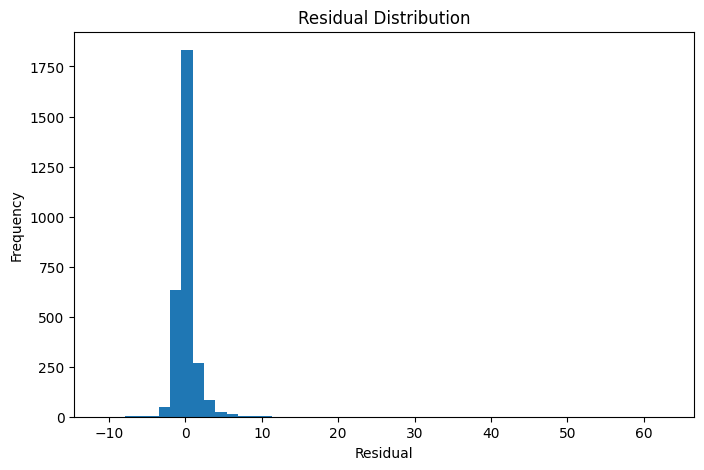

In [9]:
plt.figure(figsize=(8,5))

plt.hist(
    residuals,
    bins=50
)

plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.show()

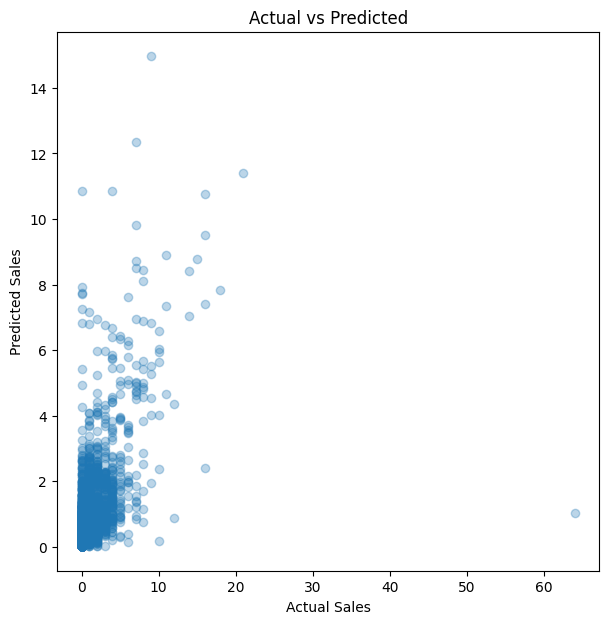

In [10]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.3
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted")

plt.show()

In [11]:
results = pd.DataFrame({
    "actual": y_test,
    "predicted": y_pred,
    "abs_error": abs(y_test - y_pred)
})

results.sort_values(
    by="abs_error",
    ascending=False
).head(20)

,actual,predicted,abs_error
77260,64,1.034613,62.965387
111205,16,2.400088,13.599912
122505,12,0.888313,11.111687
77267,0,10.858974,10.858974
77270,18,7.841240,10.158760
122499,10,0.168232,9.831768
65973,21,11.407640,9.592360
65972,16,7.414698,8.585302
77263,0,7.933627,7.933627
77266,0,7.755170,7.755170
